<a href="https://colab.research.google.com/github/1G4S/mechanical-processing/blob/main/UczenieMaszynowe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Budowa i trening modeli uczenia maszynowego

In [16]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

In [13]:
def train_models(filepath='dane_obrobka_cnc.csv'):
    print("--- ETAP 3: INICJALIZACJA MODELOWANIA XGBOOST ---")
    df = pd.read_csv(filepath)

    # 1. PRZYGOTOWANIE DANYCH (Data Preprocessing)
    # Zamiana błędu czujnika (-99.0) na NaN. XGBoost natywnie radzi sobie z brakami danych!
    df['Temp_Chlodziwa_Mean_C'] = df['Temp_Chlodziwa_Mean_C'].replace(-99.0, np.nan)

    # Zdefiniowanie cech wejściowych (X). Odrzucamy identyfikatory oraz wszystkie zmienne docelowe
    features_to_drop = ['ID_Czesci', 'ID_Narzedzia', 'Awaria_Narzedzia',
                        'Chropowatosc_Ra', 'Odchylenie_Wymiarowe', 'Klasa_Jakosci']
    X = df.drop(columns=features_to_drop)

    # =======================================================
    # MODEL 1: KLASYFIKACJA (Klasa Jakości)
    # =======================================================
    print("\nTrenowanie Modelu Klasyfikacji (Klasa_Jakosci)...")

    # Dynamiczne kodowanie klas (automatycznie przypisze 0 i 1 do istniejących klas)
    le = LabelEncoder()
    y_class = le.fit_transform(df['Klasa_Jakosci'])

    # Podział na zbiór treningowy (80%) i testowy (20%)
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X, y_class, test_size=0.2, random_state=42, stratify=y_class
    )

    # Konfiguracja i trening klasyfikatora
    clf = xgb.XGBClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        missing=np.nan
    )
    clf.fit(X_train_c, y_train_c)

    # Ewaluacja Klasyfikatora
    y_pred_c = clf.predict(X_test_c)
    print("\n--- Raport Klasyfikacji (Zbiór Testowy) ---")
    print(classification_report(y_test_c, y_pred_c, target_names=le.classes_))

    # =======================================================
    # MODEL 2: REGRESJA (Chropowatość Ra)
    # =======================================================
    print("\nTrenowanie Modelu Regresji (Chropowatosc_Ra)...")
    y_reg = df['Chropowatosc_Ra']

    # Podział danych (bez stratyfikacji, bo to zmienna ciągła)
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X, y_reg, test_size=0.2, random_state=42
    )

    # Konfiguracja i trening regresora
    reg = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        missing=np.nan
    )
    reg.fit(X_train_r, y_train_r)

    # Ewaluacja Regresora
    y_pred_r = reg.predict(X_test_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
    mae = mean_absolute_error(y_test_r, y_pred_r)
    r2 = r2_score(y_test_r, y_pred_r)

    print("\n--- Metryki Regresji (Zbiór Testowy) ---")
    print(f"RMSE (Błąd średniokwadratowy): {rmse:.4f} µm")
    print(f"MAE (Średni błąd bezwzględny): {mae:.4f} µm")
    print(f"R^2 (Współczynnik determinacji): {r2:.4f}")

    # =======================================================
    # WIZUALIZACJA WAŻNOŚCI CECH (Feature Importance)
    # =======================================================
    print("\nGenerowanie wykresów ważności cech (Feature Importance)...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Feature Importance dla Klasyfikatora
    xgb.plot_importance(clf, ax=axes[0], importance_type='gain', max_num_features=10,
                        height=0.6, title='Ważność Cech - Klasyfikator Jakości',
                        xlabel='F-Score (Zysk informacyjny)', color='steelblue')

    # Feature Importance dla Regresora
    xgb.plot_importance(reg, ax=axes[1], importance_type='gain', max_num_features=10,
                        height=0.6, title='Ważność Cech - Regresor (Chropowatość Ra)',
                        xlabel='F-Score (Zysk informacyjny)', color='darkorange')

    plt.tight_layout()
    plt.savefig('waznosc_cech_xgboost.png', bbox_inches='tight')
    plt.show()

    print("Modelowanie zakończone! Wykres zapisany jako 'waznosc_cech_xgboost.png'.")

--- ETAP 3: INICJALIZACJA MODELOWANIA XGBOOST ---

Trenowanie Modelu Klasyfikacji (Klasa_Jakosci)...

--- Raport Klasyfikacji (Zbiór Testowy) ---
              precision    recall  f1-score   support

  Do_Poprawy       0.91      0.89      0.90      1004
        Zlom       0.98      0.98      0.98      4996

    accuracy                           0.97      6000
   macro avg       0.94      0.94      0.94      6000
weighted avg       0.97      0.97      0.97      6000


Trenowanie Modelu Regresji (Chropowatosc_Ra)...

--- Metryki Regresji (Zbiór Testowy) ---
RMSE (Błąd średniokwadratowy): 0.1503 µm
MAE (Średni błąd bezwzględny): 0.0834 µm
R^2 (Współczynnik determinacji): 0.9582

Generowanie wykresów ważności cech (Feature Importance)...


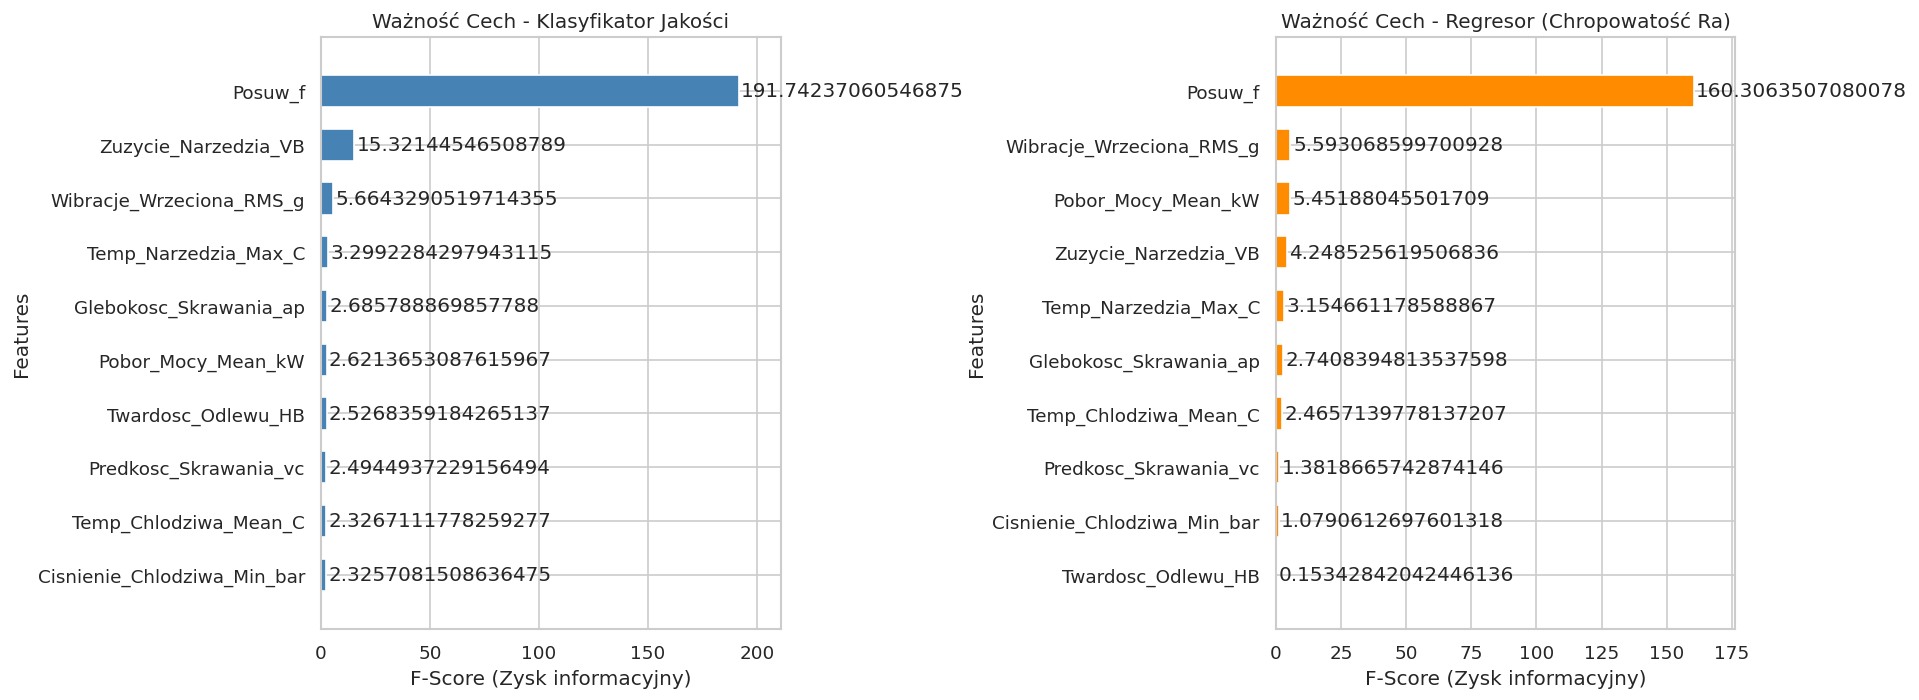

Modelowanie zakończone! Wykres zapisany jako 'waznosc_cech_xgboost.png'.


In [14]:
train_models()

**Ewaluacja modelu klasyfikacyjnego**
Ewaluacja klasyfikatora XGBoost na niezależnym zbiorze testowym (N=6000) wykazała jego wysoką skuteczność. Zbudowany model osiągnął ogólną dokładność (ang. accuracy) na poziomie 0.97. Analiza szczegółowych metryk dla poszczególnych klas dowodzi, że model radzi sobie bardzo dobrze z nierównomiernym rozkładem klas (tzw. class imbalance). Dla trudniejszej do detekcji klasy 'Do_Poprawy' (stanowiącej strefę przejściową), wskaźnik precyzji wyniósł 0.91, a czułości (ang. recall) 0.89. Z kolei dla klasy 'Zlom' zidentyfikowano prawidłowo aż 98% przypadków. Tak wysoka wartość miary F1-score (0.90 i 0.98 odpowiednio) oznacza, że wdrożenie takiego algorytmu na linii produkcyjnej zminimalizowałoby ryzyko wypuszczenia wadliwego detalu do klienta (tzw. błąd drugiego rodzaju).

**Ewaluacja modelu regresyjnego**
Model regresyjny przewidujący ciągłą wartość chropowatości powierzchni ($Ra$) wykazał doskonałe dopasowanie do danych. Współczynnik determinacji $R^2=0.9582$ wskazuje, że model jest w stanie wyjaśnić niemal 96% wariancji zmiennej docelowej wyłącznie na podstawie odczytów sensorycznych. Średni błąd bezwzględny (MAE) na poziomie zaledwie 0.0834 µm oraz błąd średniokwadratowy (RMSE) równy 0.1503 µm dowodzą, że estymacje modelu są na tyle precyzyjne, iż mogą w warunkach przemysłowych z powodzeniem pełnić funkcję wirtualnego profilometru. Błąd predykcji na poziomie ułamków mikrometra mieści się w granicach tolerancji błędu fizycznych urządzeń pomiarowych.

**Analiza Ważności Cech**
Wykresy ważności cech (ang. Feature Importance), wygenerowane w oparciu o metrykę zysku informacyjnego (ang. Gain), stanowią istotny krok w stronę wyjaśnialności modelu (XAI). W obu analizowanych przypadkach (klasyfikacja jakości oraz regresja chropowatości) bezapelacyjnie dominującym predyktorem okazał się posuw ($f$). Wynik ten jest wysoce zadowalający, ponieważ idealnie koreluje z teoretycznym modelem kinematycznym mechaniki skrawania.Warto jednak zauważyć różnice na kolejnych pozycjach: dla klasyfikatora oceniającego globalną jakość detalu drugim najistotniejszym parametrem jest poziom zużycia narzędzia ($VB$) oraz wibracje wrzeciona, co bezpośrednio wiąże się z wykrywaniem stanów awaryjnych prowadzących do powstania złomu. Z kolei dla regresora ($Ra$) nieco wyższą wagę przypisano wibracjom i poborowi mocy wrzeciona, które w fazie stabilnej pracy dokładniej modulują ostateczny profil powierzchni (tzw. chropowatość dynamiczna).

Wczytywanie danych i szybki trening modeli...
Generowanie wykresów ewaluacyjnych...


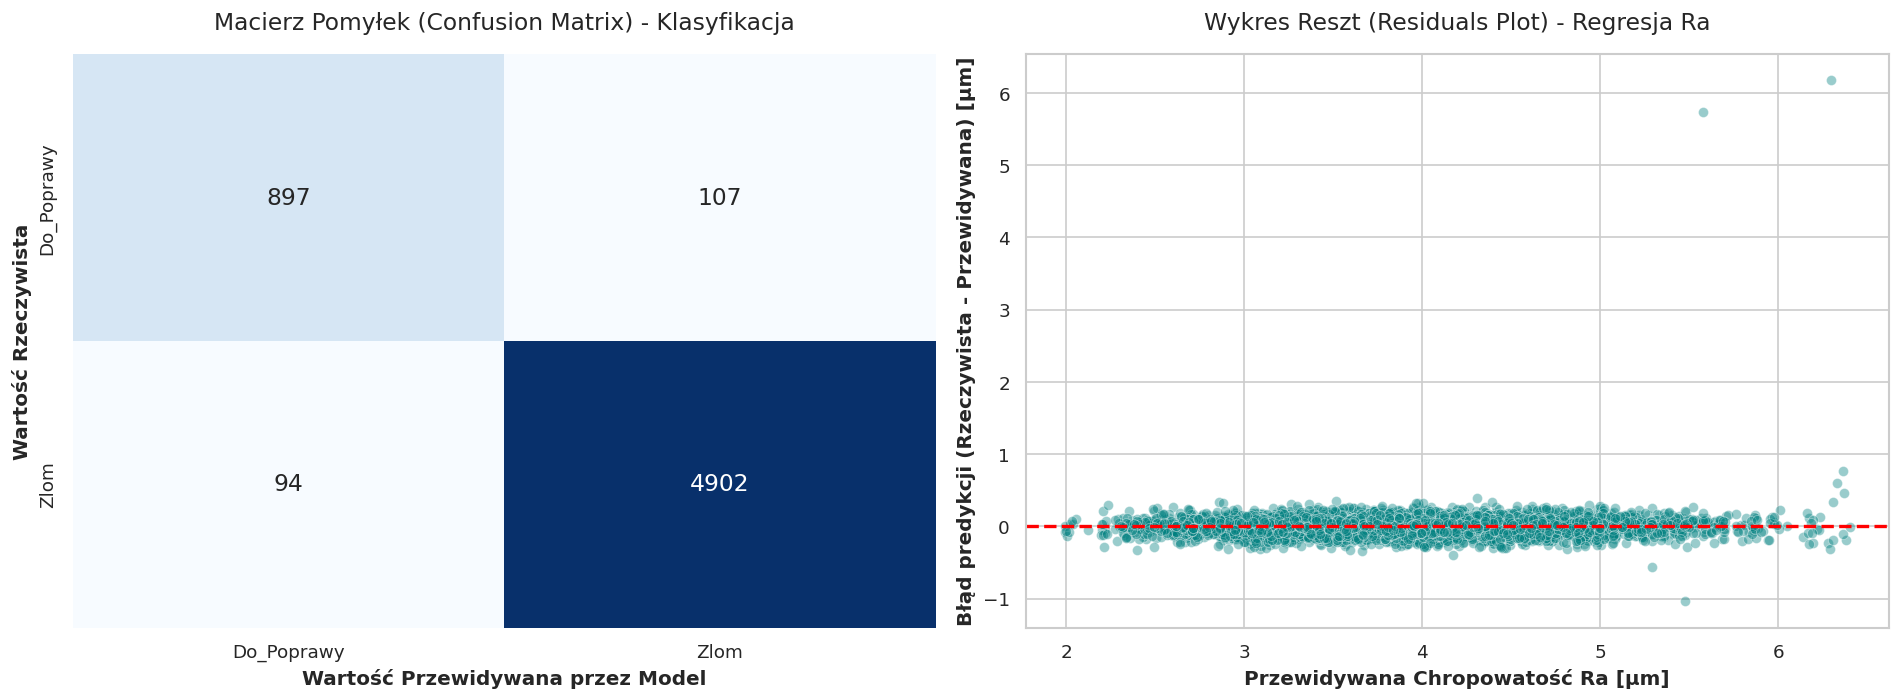

Zakończono! Wykres zapisany jako 'wykresy_ewaluacyjne.png'.


In [17]:
def generate_advanced_eval_plots(filepath='dane_obrobka_cnc.csv'):
    print("Wczytywanie danych i szybki trening modeli...")
    df = pd.read_csv(filepath)
    df['Temp_Chlodziwa_Mean_C'] = df['Temp_Chlodziwa_Mean_C'].replace(-99.0, np.nan)

    features_to_drop = ['ID_Czesci', 'ID_Narzedzia', 'Awaria_Narzedzia', 'Chropowatosc_Ra', 'Odchylenie_Wymiarowe', 'Klasa_Jakosci']
    X = df.drop(columns=features_to_drop)

    # --- KLASYFIKACJA ---
    le = LabelEncoder()
    y_class = le.fit_transform(df['Klasa_Jakosci'])
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)

    clf = xgb.XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42, missing=np.nan)
    clf.fit(X_train_c, y_train_c)
    y_pred_c = clf.predict(X_test_c)

    # --- REGRESJA ---
    y_reg = df['Chropowatosc_Ra']
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

    reg = xgb.XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42, missing=np.nan)
    reg.fit(X_train_r, y_train_r)
    y_pred_r = reg.predict(X_test_r)

    print("Generowanie wykresów ewaluacyjnych...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Macierz Pomyłek (Heatmapa)
    cm = confusion_matrix(y_test_c, y_pred_c)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=axes[0], cbar=False, annot_kws={"size": 14})
    axes[0].set_title('Macierz Pomyłek (Confusion Matrix) - Klasyfikacja', fontsize=14, pad=15)
    axes[0].set_ylabel('Wartość Rzeczywista', fontweight='bold')
    axes[0].set_xlabel('Wartość Przewidywana przez Model', fontweight='bold')

    # 2. Wykres Reszt (Residuals Plot)
    residuals = y_test_r - y_pred_r
    sns.scatterplot(x=y_pred_r, y=residuals, alpha=0.4, color='teal', ax=axes[1])
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].set_title('Wykres Reszt (Residuals Plot) - Regresja Ra', fontsize=14, pad=15)
    axes[1].set_xlabel('Przewidywana Chropowatość Ra [µm]', fontweight='bold')
    axes[1].set_ylabel('Błąd predykcji (Rzeczywista - Przewidywana) [µm]', fontweight='bold')

    plt.tight_layout()
    plt.savefig('wykresy_ewaluacyjne.png', bbox_inches='tight')
    plt.show()
    print("Zakończono! Wykres zapisany jako 'wykresy_ewaluacyjne.png'.")

generate_advanced_eval_plots()

**Analiza Macierzy Pomyłek**
Macierz pomyłek klasyfikatora XGBoost na zbiorze testowym. Wartości na przekątnej oznaczają poprawne predykcje, natomiast poza nią – błędy klasyfikacji. Rozszerzoną weryfikację modelu klasyfikacyjnego przeprowadzono z wykorzystaniem macierzy pomyłek (ang. Confusion Matrix), przedstawionej na Rysunku Y (wykres lewy). Analiza tego narzędzia jest kluczowa z perspektywy bezpieczeństwa procesu produkcyjnego. Zdecydowana większość predykcji skupia się na głównej przekątnej, co wizualnie potwierdza wysoką skuteczność algorytmu (Accuracy: 0.97). Szczególnie istotny jest fakt, że model wykazuje minimalną tendencję do generowania najgroźniejszych dla fabryki błędów (tzw. błędów drugiego rodzaju), polegających na klasyfikacji detalu wadliwego jako pełnowartościowego. Pomyłki algorytmu ograniczają się głównie do sąsiadujących ze sobą klas brzegowych (mylenie stanów 'Do_Poprawy' i 'Zlom'), co wynika z faktu wprowadzania płynnych zmian zjawisk fizycznych i naturalnego nakładania się na siebie obszarów w przestrzeni cech (udowodnionego na etapie Eksploracyjnej Analizy Danych).

**Analiza Wykresu Reszt**
Wykres reszt dla modelu regresyjnego chropowatości Ra. Czerwona linia przerywana oznacza poziom zerowego błędu. W celu weryfikacji poprawności strukturalnej modelu regresyjnego sporządzono wykres reszt (Rysunek Z, wykres prawy), obrazujący relację między wartością przewidywaną przez model a popełnionym błędem. Wykres ten udowadnia, że wygenerowane predykcje są bezstronne – błędy oscylują symetrycznie wokół wartości zerowej (czerwona linia), co oznacza, że model nie wykazuje systematycznej tendencji do zaniżania lub zawyżania chropowatości powierzchni. Ponadto, rozkład punktów wykazuje cechy homoskedastyczności, to znaczy wariancja błędu pozostaje na względnie stałym, niskim poziomie niezależnie od przewidywanej wartości Ra. Brak widocznych układów czy trendów na wykresie reszt stanowi ostateczne potwierdzenie, że model XGBoost poprawnie wychwycił sygnał nieliniowy ze zbioru danych, pozostawiając jedynie naturalny szum losowy wpisany w proces obróbki skrawaniem.


**Kwestia Hiperparametrów (Do dodania przed wynikami)**
Implementacja algorytmów opartych na drzewach (XGBoost) wymaga określenia wartości hiperparametrów sterujących architekturą modelu. W niniejszej pracy przyjęto wartości bazowe i eksperymentalne zalecane w literaturze dla problemów tabelarycznych w inżynierii produkcji. Zastosowano płytkie drzewa decyzyjne (max_depth w przedziale 4-5) w celu przeciwdziałania zjawisku przeuczenia (ang. overfitting), przy jednoczesnym zastosowaniu 150 estymatorów (drzew) i umiarkowanego współczynnika uczenia (learning_rate=0.1). Z uwagi na satysfakcjonującą wydajność (F1-score > 0.90, R² > 0.95), zrezygnowano z kosztownej obliczeniowo, wyczerpującej optymalizacji siatki (GridSearchCV), skupiając zasoby analityczne na walidacji zdolności generalizacyjnych oraz na wyjaśnialności modelu.